# Notebook 06 — Deep Learning Models (LSTM & GRU)

**Purpose:** Train recurrent neural networks on the SAME data/split as NB05,
to compare temporal DL models against the tree-based ML baseline.

## Why RNNs here
- ML models (NB05) treat each day independently (tabular).
- LSTM/GRU read a **sequence** of N past days → capture temporal patterns.

## Setup (identical to NB05, for fair comparison)
- Input: `data/processed/fx_features.csv` (4085 × 34)
- 31 features, target = next-day direction
- Chronological split 70/20/10 (no shuffle)
- Evaluated vs the same majority-class baselines

## DL-specific steps
- **StandardScaler** (fit on TRAIN only → no leakage)
- **Sequence windowing**: N past days → predict day N+1 direction

---
**Author:** Đồng Công Gia Khang · **Date:** June 2026

## 1. Setup & Device Check

In [1]:
"""
Imports, paths, device, reproducibility.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def find_project_root(marker=".env"):
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROJECT_ROOT / "figures" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
if device.type == "cuda":
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
print(f"Project: {PROJECT_ROOT}")

PyTorch: 2.5.1+cu121
Device:  cuda
GPU:     NVIDIA GeForce RTX 3050 Laptop GPU
Project: c:\Users\Khang\Desktop\Final Project 2


## 2. Load Data & Chronological Split (same as NB05)

In [2]:
"""
Load features, same 70/20/10 chronological split as NB05.
"""
df = pd.read_csv(PROCESSED_DIR / "fx_features.csv", parse_dates=["date"])

feature_cols = [c for c in df.columns
                if c not in ["date", "target_return_next_day", "target_direction"]]

n = len(df)
i70, i90 = int(n * 0.70), int(n * 0.90)
train_df = df.iloc[:i70].reset_index(drop=True)
val_df   = df.iloc[i70:i90].reset_index(drop=True)
test_df  = df.iloc[i90:].reset_index(drop=True)

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"Train UP%: {train_df['target_direction'].mean()*100:.2f}")
print(f"Val   UP%: {val_df['target_direction'].mean()*100:.2f}")
print(f"Test  UP%: {test_df['target_direction'].mean()*100:.2f}")

Features: 31
Train: 2858  Val: 817  Test: 409
Train UP%: 50.14
Val   UP%: 49.33
Test  UP%: 44.99


## 3. Scaling + Sequence Windowing

- **Scaler fit on TRAIN only** → transform val/test (no leakage).
- **Windowing per split**: N past days → next-day direction.
  Windows are built separately within each split, so no window crosses
  a train/val/test boundary.

In [3]:
"""
Scale (fit on train) and build sequence windows.
"""
WINDOW = 10   # use 10 past days to predict the next day

scaler = StandardScaler()
X_train_s = scaler.fit_transform(train_df[feature_cols])   # FIT on train
X_val_s   = scaler.transform(val_df[feature_cols])         # transform only
X_test_s  = scaler.transform(test_df[feature_cols])

y_train_a = train_df["target_direction"].values
y_val_a   = val_df["target_direction"].values
y_test_a  = test_df["target_direction"].values


def make_windows(X, y, window):
    """X[i-window:i] -> y[i].  Returns 3D array [samples, window, features]."""
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


Xtr, ytr = make_windows(X_train_s, y_train_a, WINDOW)
Xva, yva = make_windows(X_val_s,   y_val_a,   WINDOW)
Xte, yte = make_windows(X_test_s,  y_test_a,  WINDOW)

print(f"Window size: {WINDOW} days")
print(f"Train windows: {Xtr.shape}  (samples, timesteps, features)")
print(f"Val   windows: {Xva.shape}")
print(f"Test  windows: {Xte.shape}")

# Baselines on the WINDOWED targets (for fair comparison)
VAL_BASE  = max(yva.mean(),  1 - yva.mean())
TEST_BASE = max(yte.mean(),  1 - yte.mean())
print(f"\nVal baseline:  {VAL_BASE*100:.2f}%")
print(f"Test baseline: {TEST_BASE*100:.2f}%")

Window size: 10 days
Train windows: (2848, 10, 31)  (samples, timesteps, features)
Val   windows: (807, 10, 31)
Test  windows: (399, 10, 31)

Val baseline:  50.56%
Test baseline: 54.39%


## 4. Model Definitions (LSTM & GRU)

A recurrent layer reads the 10-day sequence, the last hidden state is
passed to a small classifier head. Dropout + weight decay control
overfitting (our ML models overfit hard, so DL needs regularization too).

In [4]:
"""
Shared RNN classifier: switch between LSTM and GRU via rnn_type.
"""
class RNNClassifier(nn.Module):
    def __init__(self, n_features, hidden=32, num_layers=1,
                 dropout=0.3, rnn_type="LSTM"):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),   # 1 logit -> sigmoid later
        )

    def forward(self, x):
        out, _ = self.rnn(x)        # out: [batch, timesteps, hidden]
        last = out[:, -1, :]        # take last timestep's hidden state
        return self.head(last).squeeze(-1)   # [batch]


n_features = Xtr.shape[2]
print("Model class ready. n_features =", n_features)

Model class ready. n_features = 31


## 5. Training Loop (with early stopping on validation)

- Loss: BCEWithLogitsLoss (binary classification)
- Optimizer: Adam + weight decay (L2 regularization)
- Early stopping: keep the weights with best validation accuracy
- Model selection uses VALIDATION only; test is touched once at the end.

In [5]:
"""
Reusable training routine.
"""
# Tensors -> DataLoader (train shuffled is OK: windows are fixed,
# shuffling only reorders independent samples within the training set)
def to_loader(X, y, batch=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

train_loader = to_loader(Xtr, ytr, shuffle=True)

Xva_t = torch.tensor(Xva).to(device)
Xte_t = torch.tensor(Xte).to(device)


@torch.no_grad()
def predict(model, X_t):
    model.eval()
    logits = model(X_t)
    return (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()


def train_model(rnn_type, epochs=80, lr=1e-3, weight_decay=1e-4, patience=12):
    torch.manual_seed(SEED)
    model = RNNClassifier(n_features, rnn_type=rnn_type).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    best_val, best_state, wait = 0.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        val_acc = accuracy_score(yva, predict(model, Xva_t))
        if val_acc > best_val:
            best_val, best_state, wait = val_acc, \
                {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    print(f"{rnn_type}: best val acc = {best_val*100:.2f}% (stopped at epoch {ep})")
    return model

print("Training routine ready.")

Training routine ready.


## 6. Train LSTM & GRU

In [6]:
"""
Train both recurrent models (early stopping on validation).
"""
lstm_model = train_model("LSTM")
gru_model  = train_model("GRU")

LSTM: best val acc = 53.78% (stopped at epoch 15)
GRU: best val acc = 53.41% (stopped at epoch 14)


## 7. Evaluate vs Baselines & ML Models

In [7]:
"""
Final evaluation on val + test, compared to baselines and NB05 ML results.
"""
def full_eval(name, model):
    tr_acc = accuracy_score(ytr, predict(model, torch.tensor(Xtr).to(device)))
    va_acc = accuracy_score(yva, predict(model, Xva_t))
    te_acc = accuracy_score(yte, predict(model, Xte_t))
    print(f"=== {name} ===")
    print(f"Train: {tr_acc*100:5.2f}%   (overfit check)")
    print(f"Val:   {va_acc*100:5.2f}%   vs baseline {VAL_BASE*100:.2f}%  ({(va_acc-VAL_BASE)*100:+.2f} pp)")
    print(f"Test:  {te_acc*100:5.2f}%   vs baseline {TEST_BASE*100:.2f}%  ({(te_acc-TEST_BASE)*100:+.2f} pp)")
    return {"train": tr_acc, "val": va_acc, "test": te_acc}

dl_results = {}
dl_results["LSTM"] = full_eval("LSTM", lstm_model)
dl_results["GRU"]  = full_eval("GRU",  gru_model)

# Merge with ML results from NB05 for the full comparison
print("\n" + "=" * 60)
print("FULL COMPARISON — all 5 models")
print("=" * 60)

ml_path = MODELS_DIR / "ml_results.csv"
if ml_path.exists():
    ml = pd.read_csv(ml_path, index_col=0)
    ml.columns = [c.replace(" %", "").lower() for c in ml.columns]
    ml = ml[["train", "val", "test"]]
else:
    ml = pd.DataFrame()

dl = pd.DataFrame(dl_results).T * 100
allm = pd.concat([ml, dl]).round(2)
allm["val_vs_base"] = (allm["val"] - VAL_BASE*100).round(2)
print(allm.to_string())
print(f"\nVal baseline {VAL_BASE*100:.2f}% | Test baseline {TEST_BASE*100:.2f}%")

=== LSTM ===
Train: 54.49%   (overfit check)
Val:   53.78%   vs baseline 50.56%  (+3.22 pp)
Test:  47.37%   vs baseline 54.39%  (-7.02 pp)
=== GRU ===
Train: 53.41%   (overfit check)
Val:   53.41%   vs baseline 50.56%  (+2.85 pp)
Test:  52.13%   vs baseline 54.39%  (-2.26 pp)

FULL COMPARISON — all 5 models
               train    val   test  val_vs_base
Random Forest  75.89  51.53  47.92         0.97
XGBoost        76.24  50.43  44.01        -0.13
LightGBM       78.31  51.90  45.72         1.34
LSTM           54.49  53.78  47.37         3.22
GRU            53.41  53.41  52.13         2.85

Val baseline 50.56% | Test baseline 54.39%


## 8. Save Models & Comparison Chart

Saved lstm.pt, gru.pt
Saved all_models_results.csv


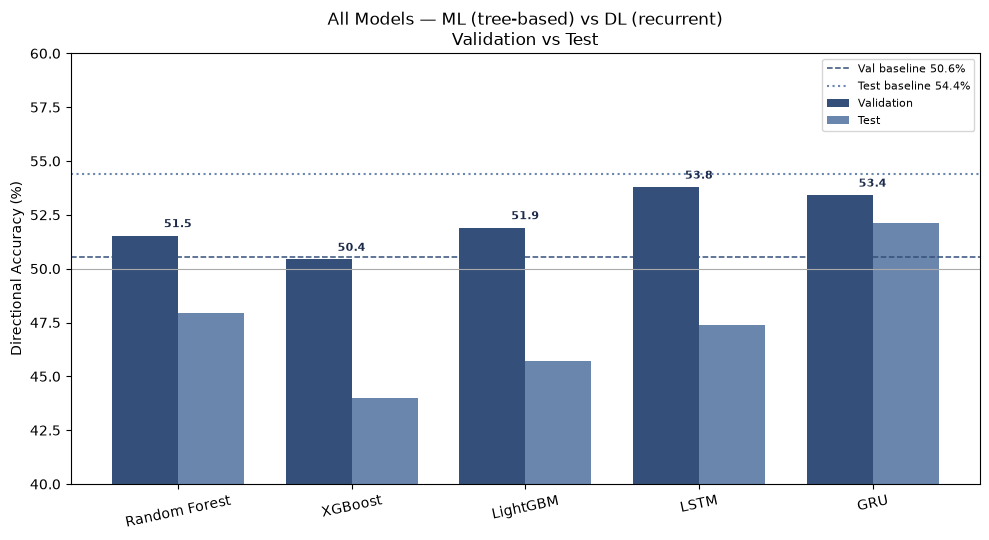


Model selection (by validation):
  Best: LSTM  (val 53.78%, +3.22 pp over baseline)


In [8]:
"""
Persist DL models + combined 5-model comparison.
"""
# Save model weights
torch.save(lstm_model.state_dict(), MODELS_DIR / "lstm.pt")
torch.save(gru_model.state_dict(),  MODELS_DIR / "gru.pt")
print("Saved lstm.pt, gru.pt")

# Save combined results
allm.to_csv(MODELS_DIR / "all_models_results.csv")
print("Saved all_models_results.csv")

# Comparison chart: Val vs Test for all 5 models
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(allm))
w = 0.38
ax.bar(x - w/2, allm["val"],  w, label="Validation", color="#34507a")
ax.bar(x + w/2, allm["test"], w, label="Test",       color="#6b86ad")
ax.axhline(VAL_BASE*100,  color="#34507a", ls="--", lw=1.1, label=f"Val baseline {VAL_BASE*100:.1f}%")
ax.axhline(TEST_BASE*100, color="#6b86ad", ls=":",  lw=1.5, label=f"Test baseline {TEST_BASE*100:.1f}%")
ax.axhline(50, color="#aaaaaa", lw=0.8)

# highlight model type
for i, name in enumerate(allm.index):
    ax.text(i, allm["val"].iloc[i] + 0.4, f'{allm["val"].iloc[i]:.1f}',
            ha="center", fontsize=8, color="#1b2a4a", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(allm.index, rotation=12)
ax.set_ylabel("Directional Accuracy (%)")
ax.set_ylim(40, 60)
ax.set_title("All Models — ML (tree-based) vs DL (recurrent)\nValidation vs Test")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_all_models_comparison.png", dpi=120)
plt.show()

print("\nModel selection (by validation):")
best = allm["val"].idxmax()
print(f"  Best: {best}  (val {allm.loc[best,'val']:.2f}%, +{allm.loc[best,'val']-VAL_BASE*100:.2f} pp over baseline)")

In [9]:
"""
Standalone: refit and save the direction scaler (train-only fit).
"""
from pathlib import Path
import pandas as pd
import numpy as np
import joblib, json
from sklearn.preprocessing import StandardScaler

def _root(marker=".env"):
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / marker).exists():
            return p
    return Path.cwd()

ROOT = _root()
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(ROOT / "data" / "processed" / "fx_features.csv", parse_dates=["date"])
feature_cols = [c for c in df.columns
                if c not in ["date", "target_return_next_day", "target_direction"]]

n = len(df)
i70 = int(n * 0.70)
train_X = df.iloc[:i70][feature_cols]

scaler = StandardScaler().fit(train_X)          # FIT ON TRAIN ONLY
joblib.dump(scaler, MODELS_DIR / "scaler_direction.pkl")

meta = {"feature_cols": feature_cols, "window": 10, "train_rows": int(i70)}
with open(MODELS_DIR / "direction_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved scaler_direction.pkl + direction_meta.json")
print(f"Fitted on {scaler.n_features_in_} features, {i70} train rows")

Saved scaler_direction.pkl + direction_meta.json
Fitted on 31 features, 2858 train rows
